In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPORTS_DIR = "../reports"
os.makedirs(REPORTS_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(REPORTS_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

train = pd.read_csv("../data/raw/UNSW_NB15_training-set.csv")
test  = pd.read_csv("../data/raw/UNSW_NB15_testing-set.csv")

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

a = pd.read_csv("../data/raw/UNSW_NB15_training-set.csv")
b = pd.read_csv("../data/raw/UNSW_NB15_testing-set.csv")
train, test = (a, b) if len(a) > len(b) else (b, a)
print(train.shape, test.shape)   # expect (175341, 45) and (82332, 45)

(175341, 45) (82332, 45)


In [15]:
# Data types and column split
print(train.dtypes.value_counts())
cat_cols = train.select_dtypes(include="object").columns.tolist()
num_cols = train.select_dtypes(exclude="object").columns.tolist()
print("Categorical:", cat_cols)
print("Numerical count:", len(num_cols))

int64      30
float64    11
str         4
Name: count, dtype: int64
Categorical: ['proto', 'service', 'state', 'attack_cat']
Numerical count: 41


/tmp/ipykernel_38601/1021616915.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include="object").columns.tolist()


In [16]:
# Data quality
print("Missing values:", train.isna().sum().sum())
print("Duplicates (excluding id):", train.drop(columns="id").duplicated().sum())
print("Infinite values:", np.isinf(train.select_dtypes(include="number")).sum().sum())

Missing values: 0
Duplicates (excluding id): 67601
Infinite values: 0


label
1    119341
0     56000
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


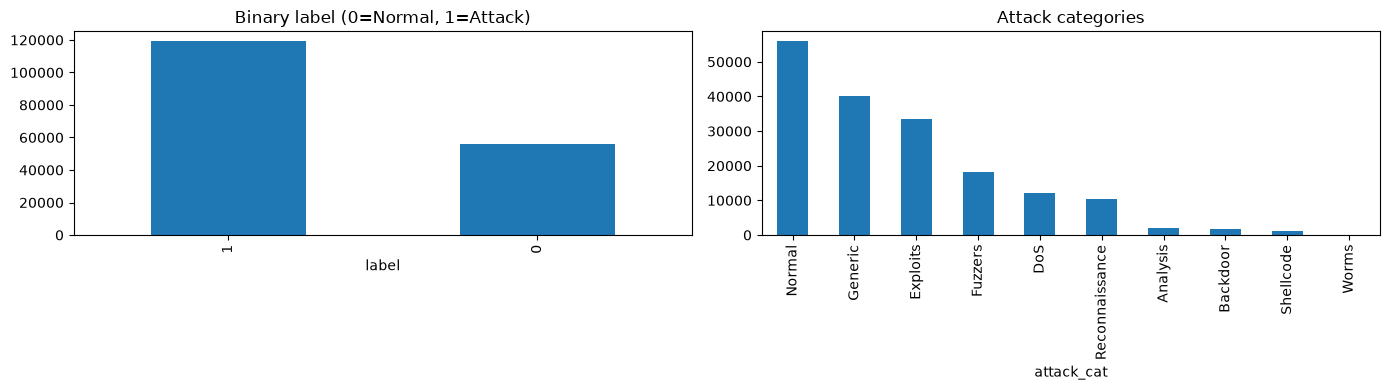

In [17]:
# Target distribution
print(train["label"].value_counts())
print(train["attack_cat"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
train["label"].value_counts().plot.bar(ax=ax[0], title="Binary label (0=Normal, 1=Attack)")
train["attack_cat"].value_counts().plot.bar(ax=ax[1], title="Attack categories")
plt.tight_layout(); plt.show()

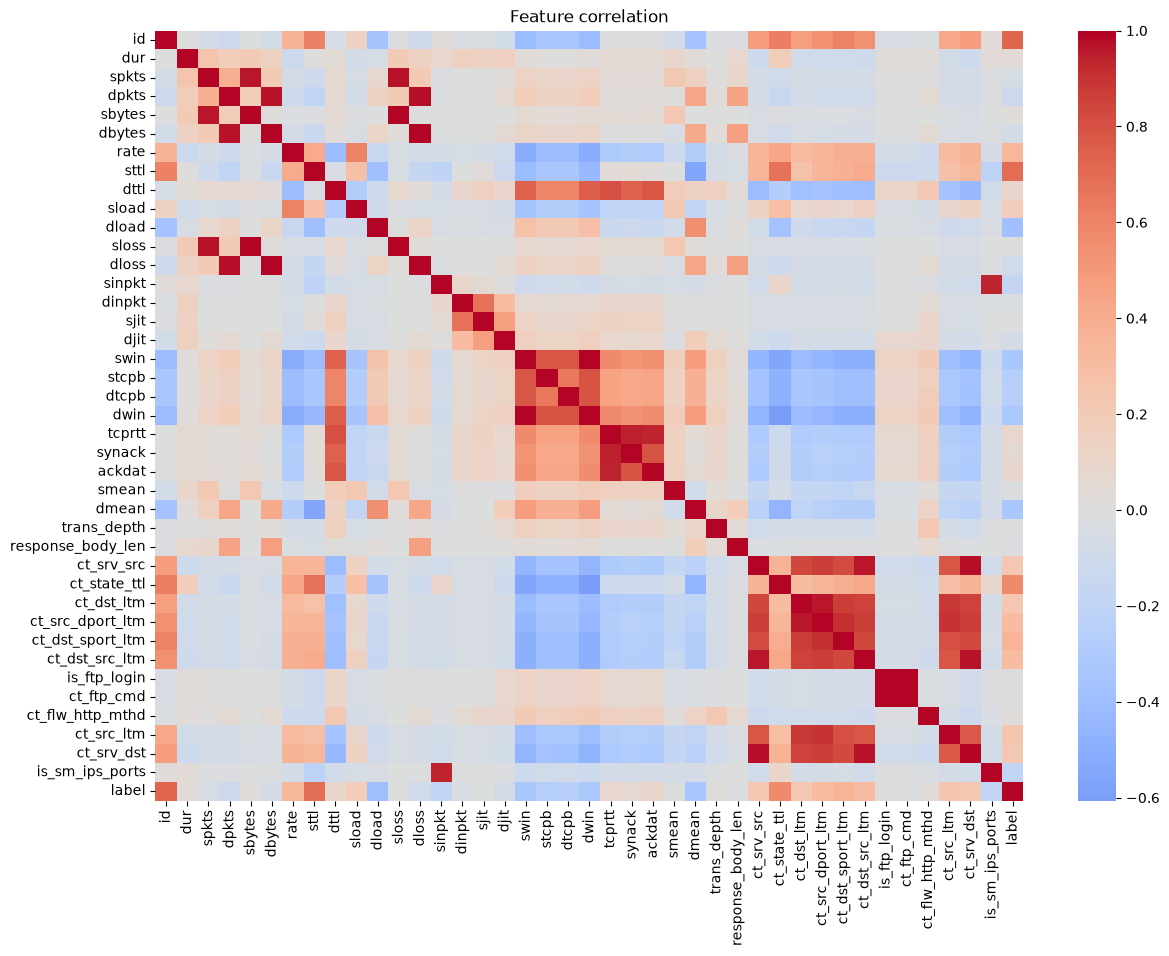

In [18]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation"); plt.show()

Saved: ../reports/01_class_distribution.png


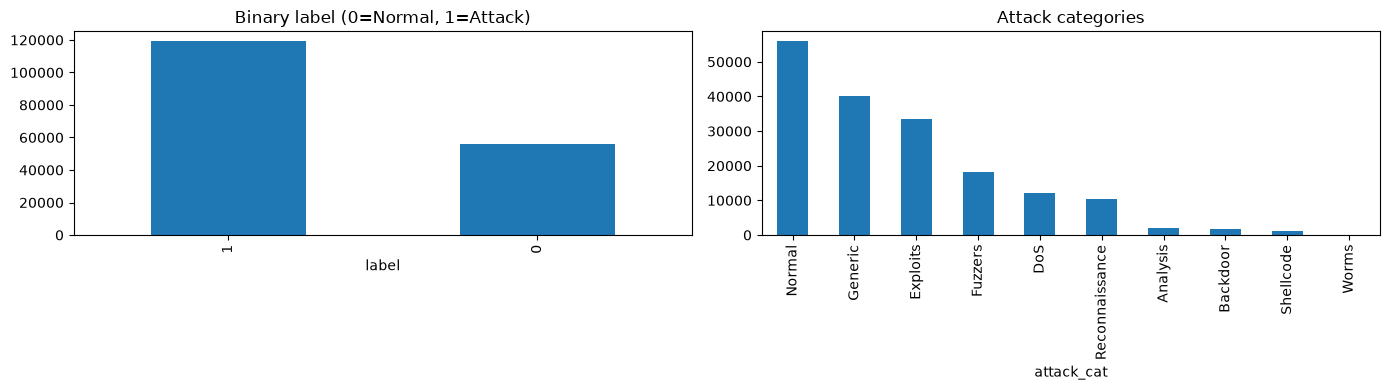

In [19]:
# Class distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
train["label"].value_counts().plot.bar(ax=ax[0], title="Binary label (0=Normal, 1=Attack)")
train["attack_cat"].value_counts().plot.bar(ax=ax[1], title="Attack categories")
plt.tight_layout()
save_fig("01_class_distribution.png")
plt.show()

Saved: ../reports/02_correlation_heatmap.png


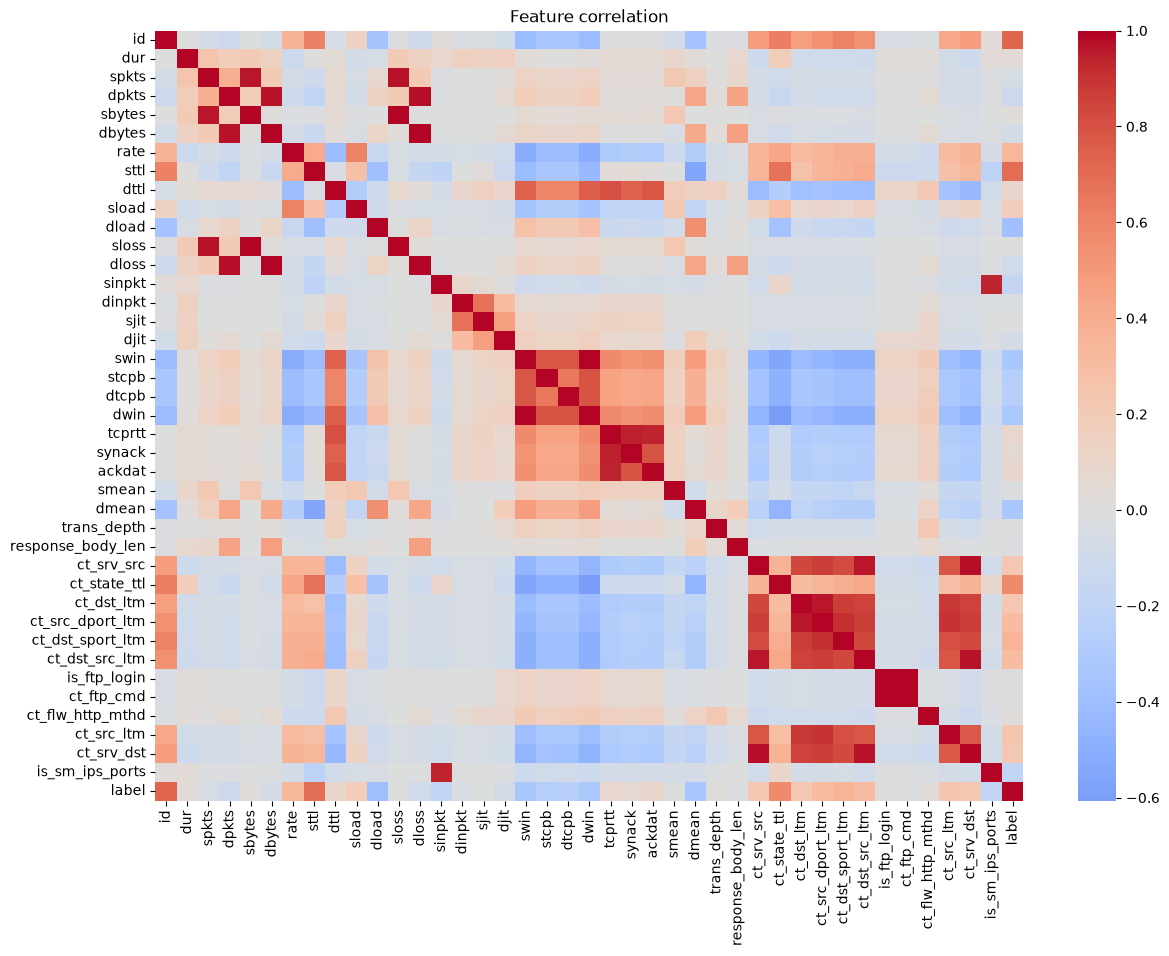

In [20]:
# Correlation heatmap

num_cols = train.select_dtypes(exclude="object").columns.tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation")
save_fig("02_correlation_heatmap.png")
plt.show()

Saved: ../reports/03_feature_distributions.png


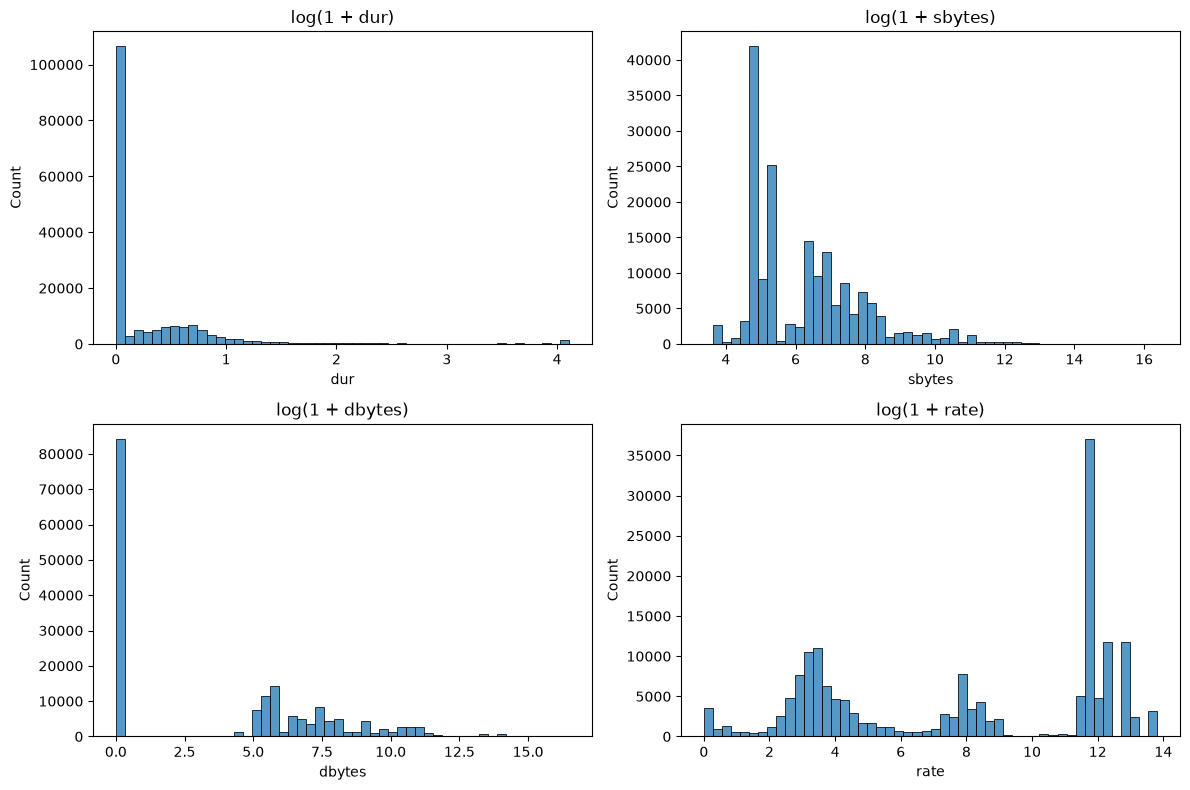

In [21]:
# Top feature distributions

features = ["dur", "sbytes", "dbytes", "rate"]   # adjust if a column name differs

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(np.log1p(train[col]), bins=50, ax=ax)
    ax.set_title(f"log(1 + {col})")
plt.tight_layout()
save_fig("03_feature_distributions.png")
plt.show()

Saved: ../reports/04_attack_categories.png


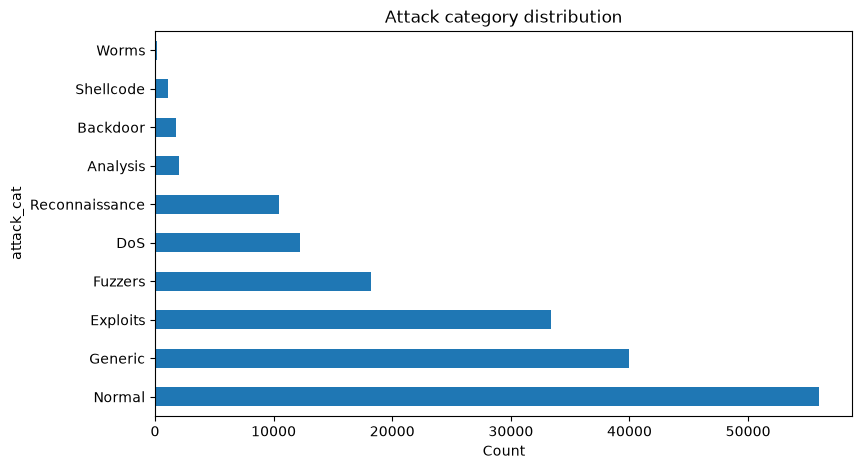

In [22]:
# Attack category distribution (separate chart)

plt.figure(figsize=(9, 5))
train["attack_cat"].value_counts().plot.barh()
plt.title("Attack category distribution")
plt.xlabel("Count")
save_fig("04_attack_categories.png")
plt.show()

In [23]:
summary = f"""Dataset Name: UNSW-NB15 (partitioned training/testing sets)
Train records: {train.shape[0]}
Test records: {test.shape[0]}
Number of columns: {train.shape[1]}
Target columns: label (binary), attack_cat (multi-class)
Number of attack categories: {train['attack_cat'].nunique()}
Categorical features: {train.select_dtypes(include='object').columns.tolist()}
Numerical feature count: {len(num_cols)}
Missing values: {int(train.isna().sum().sum())}
Duplicate records (excluding id): {int(train.drop(columns='id').duplicated().sum())}
Infinite values: {int(np.isinf(train.select_dtypes(include='number')).sum().sum())}

Binary label counts:
{train['label'].value_counts().to_string()}

Attack category counts:
{train['attack_cat'].value_counts().to_string()}
"""

with open(os.path.join(REPORTS_DIR, "dataset_summary.txt"), "w") as f:
    f.write(summary)

print(summary)

/tmp/ipykernel_38601/3629083886.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical features: {train.select_dtypes(include='object').columns.tolist()}


Dataset Name: UNSW-NB15 (partitioned training/testing sets)
Train records: 175341
Test records: 82332
Number of columns: 45
Target columns: label (binary), attack_cat (multi-class)
Number of attack categories: 10
Categorical features: ['proto', 'service', 'state', 'attack_cat']
Numerical feature count: 41
Missing values: 0
Duplicate records (excluding id): 67601
Infinite values: 0

Binary label counts:
label
1    119341
0     56000

Attack category counts:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130

